**Student:** Aimen A Ali Etorki

**Student Number: 30095294**

**Year:** Feb 2025 Intake

**Supervisor:** Dr Mabrouka Abuhmida

**MSc Project:** CS4T702_2025/26 Artificial Intelligence 

**Project Title:**  Explainable Hybrid AI Model for Early Detection of Alzheimer’s Disease Using MRI-Derived Hippocampal and Brain Structural Features

# Notebook 2: Reading and Reconstructing ADNI DICOM MRI Data

## Objective

Load ADNI MPRAGE MRI data from raw DICOM, verify spatial ordering and series
consistency, reconstruct the 3D volume, and validate acquisition parameters across
the whole cohort.

## DICOM Processing Approach

The DICOM data are processed using spatial information from
`ImagePositionPatient` to determine the correct slice order. This is more
reliable than relying on filenames or `InstanceNumber` and ensures that the
3D MRI volume is reconstructed consistently.

The notebook includes three main components:

- **Shared MRI utility module.** Common MRI loading and reconstruction functions
  are stored in `src/mri_utils.py` and reused by notebooks 3 and 4. This keeps
  the DICOM processing procedure consistent across the pipeline.

- **Series discovery and validation.** Acquisition and series folders are
  identified and checked explicitly, particularly when multiple acquisitions
  or series are available for the same participant.

- **Cohort-wide acquisition audit.** Scanner manufacturer, field strength, voxel
  spacing and matrix size are examined across the cohort. This helps identify
  acquisition-related differences that could act as potential confounding
  factors if the model learns scanner characteristics rather than
  disease-related patterns.

In [1]:
# ============================================================
# Project Configuration
#
# The project root is identified automatically so that file paths
# remain relative to the project structure rather than depending
# on a specific computer or user directory.
# ============================================================

from pathlib import Path


def find_project_root(marker_folders=("MRI 1.5T & 3T Dataset", "notebooks")):
    """Walk upwards until a folder containing the project markers is found."""

    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if any((candidate / m).exists() for m in marker_folders):
            return candidate

    # Fall back to the original absolute path
    return Path(r"C:\Users\aimen\Documents\GitHub\MSc-Final-Project")


PROJECT_ROOT = find_project_root()

RAW_DATA = PROJECT_ROOT / "MRI 1.5T & 3T Dataset"
MRI_FOLDER = RAW_DATA / "ADNI"

CSV_FILE = PROJECT_ROOT / "MRI_1.5T___3T_Dataset_7_08_2026.csv"

PROCESSED_DATA = PROJECT_ROOT / "processed"
DATASET_FOLDER = PROJECT_ROOT / "dataset"
FINAL_DATASET_FOLDER = PROJECT_ROOT / "final_dataset"
MODELS_FOLDER = PROJECT_ROOT / "models"
RESULTS_FOLDER = PROJECT_ROOT / "results"
SRC_FOLDER = PROJECT_ROOT / "src"

for folder in [PROCESSED_DATA, DATASET_FOLDER, FINAL_DATASET_FOLDER,
               MODELS_FOLDER, RESULTS_FOLDER, SRC_FOLDER]:
    folder.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["CN", "MCI", "AD"]
RANDOM_SEED = 42

print("PROJECT_ROOT :", PROJECT_ROOT)
print()
print("Path check")
print("-" * 46)
for label, path in [
    ("MRI folder    ", MRI_FOLDER),
    ("Metadata CSV  ", CSV_FILE),
    ("Processed     ", PROCESSED_DATA),
    ("Final dataset ", FINAL_DATASET_FOLDER),
    ("Source module ", SRC_FOLDER),
]:
    status = "OK " if path.exists() else "MISSING"
    print(f"{label}: [{status}] {path}")

PROJECT_ROOT : C:\Users\aimen\Documents\GitHub\MSc-Final-Project

Path check
----------------------------------------------
MRI folder    : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\MRI 1.5T & 3T Dataset\ADNI
Metadata CSV  : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\MRI_1.5T___3T_Dataset_7_08_2026.csv
Processed     : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\processed
Final dataset : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\final_dataset
Source module : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\src


In [2]:
# ============================================================
# Libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom

from collections import Counter

print("pydicom version:", pydicom.__version__)

pydicom version: 3.0.2


## 2.1 Robust MRI Series Discovery

The ADNI directory structure used in this project is:

```
ADNI/<Subject>/<SequenceName>/<AcquisitionDate>/<SeriesUID>/*.dcm
```

A participant may contain multiple sequence, acquisition, or series folders.
Therefore, MRI series are identified explicitly rather than assuming that the
first available folder contains the required data.

The function below searches the available series, prioritises MPRAGE acquisitions,
and selects the candidate containing the largest number of DICOM files. This helps
ensure that a complete MRI series is selected while also handling empty or
incomplete folders safely.

In [3]:
# ============================================================
# Series Discovery
# ============================================================

def find_mri_series(participant_folder, prefer=("MPRAGE", "MP-RAGE", "MP RAGE")):
    """
    Locate candidate DICOM series folders for one participant.

    Returns a list of dicts sorted best-first, each containing the
    series path, sequence name, acquisition folder name and file count.
    """

    participant_folder = Path(participant_folder)

    if not participant_folder.exists():
        raise FileNotFoundError(f"No folder for {participant_folder.name}")

    candidates = []

    # Search through sequence / acquisition / series
    for sequence_folder in sorted(participant_folder.iterdir()):

        if not sequence_folder.is_dir():
            continue

        for acquisition_folder in sorted(sequence_folder.iterdir()):

            if not acquisition_folder.is_dir():
                continue

            for series_folder in sorted(acquisition_folder.iterdir()):

                if not series_folder.is_dir():
                    continue

                dicom_files = list(series_folder.glob("*.dcm"))

                if not dicom_files:
                    continue

                sequence_name = sequence_folder.name

                is_preferred = any(
                    token.lower() in sequence_name.lower()
                    for token in prefer
                )

                candidates.append({
                    "path": series_folder,
                    "sequence": sequence_name,
                    "acquisition": acquisition_folder.name,
                    "n_files": len(dicom_files),
                    "preferred": is_preferred,
                })

    if not candidates:
        raise FileNotFoundError(
            f"No DICOM series found for {participant_folder.name}"
        )

    # Preferred sequences first, then the series with most slices
    candidates.sort(key=lambda c: (not c["preferred"], -c["n_files"]))

    return candidates


# ------------------------------------------------------------
# Demonstrate on one participant
# ------------------------------------------------------------

participant_id = "013_S_0996"

candidates = find_mri_series(MRI_FOLDER / participant_id)

print(f"Series found for {participant_id}: {len(candidates)}\n")

for i, candidate in enumerate(candidates):
    marker = "  <- selected" if i == 0 else ""
    print(f"  [{i}] {candidate['sequence']:<12} "
          f"{candidate['acquisition'][:20]:<22} "
          f"{candidate['n_files']:>4} files"
          f"{' (preferred)' if candidate['preferred'] else ''}{marker}")

dicom_folder = candidates[0]["path"]

Series found for 013_S_0996: 3

  [0] MPRAGE       2006-11-06_14_53_40.    160 files (preferred)  <- selected
  [1] MPRAGE       2007-01-03_13_32_28.    160 files (preferred)
  [2] MPRAGE       2007-01-03_13_56_25.    160 files (preferred)


## 2.2 Volume Reconstruction

DICOM filenames do not reliably encode anatomical position. The correct ordering
comes from the spatial metadata:

`ImageOrientationPatient` gives the direction cosines of the image rows and
columns. Their cross product is the slice-normal vector. Projecting each slice's
`ImagePositionPatient` onto that normal gives its physical position along the
acquisition axis, which is a true anatomical ordering independent of how the files
happen to be named or numbered.

Series consistency is enforced during reconstruction, and slice spacing uniformity
is checked, since a large gap may indicate missing slices that could distort the
reconstructed volume.

In [4]:
# ============================================================
# Load and Reconstruct
# ============================================================

def load_mri_volume(dicom_folder, enforce_single_series=True,
                    spacing_tolerance=0.30):
    """
    Load a DICOM series, order slices anatomically, and reconstruct
    the 3D volume.

    Returns (volume, slices, info).
    """

    dicom_folder = Path(dicom_folder)
    dicom_files = list(dicom_folder.glob("*.dcm"))

    if not dicom_files:
        raise ValueError(f"No DICOM files in {dicom_folder}")

    slices = [pydicom.dcmread(f) for f in dicom_files]

    # ---- series consistency ----
    series_uids = {str(s.SeriesInstanceUID) for s in slices}

    if len(series_uids) > 1:
        message = (f"{len(series_uids)} different SeriesInstanceUIDs in "
                   f"{dicom_folder.name} - these are not one acquisition")
        if enforce_single_series:
            raise ValueError(message)
        print("WARNING:", message)

    # ---- spatial ordering ----
    orientation = np.array(slices[0].ImageOrientationPatient, dtype=float)

    row_direction = orientation[:3]
    column_direction = orientation[3:]
    slice_normal = np.cross(row_direction, column_direction)

    def slice_position(dicom_slice):
        position = np.array(dicom_slice.ImagePositionPatient, dtype=float)
        return float(np.dot(position, slice_normal))

    slices = sorted(slices, key=slice_position)

    # ---- spacing uniformity ----
    positions = np.array([slice_position(s) for s in slices])
    spacings = np.abs(np.diff(positions))

    median_spacing = float(np.median(spacings))

    spacing_uniform = bool(
        np.all(np.abs(spacings - median_spacing)
               <= spacing_tolerance * median_spacing)
    )

    # ---- reconstruct ----
    volume = np.stack([s.pixel_array for s in slices])

    first = slices[0]

    info = {
        "n_slices": len(slices),
        "shape": volume.shape,
        "dtype": str(volume.dtype),
        "row_spacing": float(first.PixelSpacing[0]),
        "column_spacing": float(first.PixelSpacing[1]),
        "slice_spacing": median_spacing,
        "spacing_uniform": spacing_uniform,
        "max_spacing_deviation": float(
            np.max(np.abs(spacings - median_spacing))) if len(spacings) else 0.0,
        "manufacturer": str(getattr(first, "Manufacturer", "Unknown")).strip(),
        "model": str(getattr(first, "ManufacturerModelName", "Unknown")).strip(),
        "field_strength": float(getattr(first, "MagneticFieldStrength", np.nan)),
        "series_description": str(getattr(first, "SeriesDescription", "")).strip(),
        "patient_id": str(getattr(first, "PatientID", "")).strip(),
        "n_series_uids": len(series_uids),
    }

    return volume, slices, info


# ------------------------------------------------------------
# Run on the representative participant
# ------------------------------------------------------------

volume, slices, info = load_mri_volume(dicom_folder)

print(f"Participant: {participant_id}\n")

for key, value in info.items():
    print(f"  {key:<24}: {value}")

if not info["spacing_uniform"]:
    print("\nWARNING: slice spacing is not uniform. This can indicate")
    print("missing slices and will distort any 3D measurement.")

Participant: 013_S_0996

  n_slices                : 160
  shape                   : (160, 192, 192)
  dtype                   : uint16
  row_spacing             : 1.25
  column_spacing          : 1.25
  slice_spacing           : 1.200000000000001
  spacing_uniform         : True
  max_spacing_deviation   : 3.019806626980426e-13
  manufacturer            : SIEMENS
  model                   : Sonata
  field_strength          : 1.4939999580383
  series_description      : MPRAGE
  patient_id              : 013_S_0996
  n_series_uids           : 1


c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.02871115258695046335'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


In [5]:
# ============================================================
# Intensity Range
# ============================================================

nonzero = volume[volume > 0]

print("Raw intensity statistics")
print("-" * 40)
print(f"  Non-zero voxels : {nonzero.size:,} "
      f"({nonzero.size / volume.size:.1%} of volume)")
print(f"  Minimum         : {nonzero.min()}")
print(f"  Maximum         : {volume.max()}")
print(f"  Mean            : {nonzero.mean():.1f}")
print(f"  Median          : {np.median(nonzero):.1f}")

# Display window shared by every figure below, so that low-signal
# edge slices are not artificially amplified by per-image scaling
display_min = np.percentile(nonzero, 1)
display_max = np.percentile(nonzero, 99.5)

print(f"\n  Display window  : [{display_min:.0f}, {display_max:.0f}]")

Raw intensity statistics
----------------------------------------
  Non-zero voxels : 5,827,327 (98.8% of volume)
  Minimum         : 1
  Maximum         : 1049
  Mean            : 91.6
  Median          : 23.0

  Display window  : [2, 588]


## 2.3 Quality-Control Visualisation

Two checks are performed. First, sagittal coverage across the reconstructed volume
is inspected to confirm that anatomical structures progress smoothly and that the
slice ordering is correct. Second, the three orthogonal planes are displayed using
aspect ratios derived from the DICOM voxel spacing.

Correct aspect ratios are important because MRI voxels are not always perfectly
isotropic. Displaying reformatted planes without accounting for voxel spacing can
distort the apparent anatomy and make visual quality assessment less reliable.

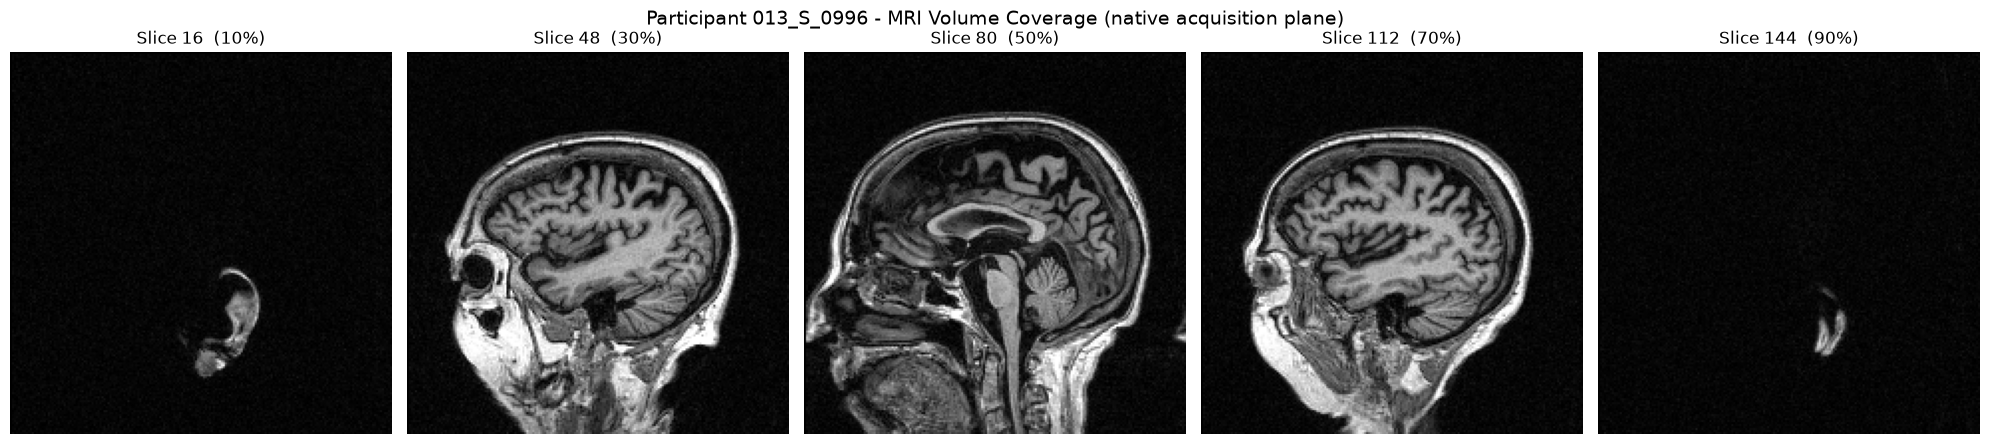

This figure verifies that the DICOM slices are ordered correctly
along the acquisition axis and that anatomical coverage progresses
smoothly across the reconstructed volume.
The analysis itself uses coronal slices - see Notebook 3.


In [6]:
# ============================================================
# MRI Volume Coverage
# ============================================================

fractions = [0.10, 0.30, 0.50, 0.70, 0.90]
indices = [int(len(volume) * f) for f in fractions]

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))

for ax, idx, fraction in zip(axes, indices, fractions):
    ax.imshow(volume[idx], cmap="gray", vmin=display_min, vmax=display_max)
    ax.set_title(f"Slice {idx}  ({fraction:.0%})")
    ax.axis("off")

plt.suptitle(
    f"Participant {participant_id} - MRI Volume Coverage "
    f"(native acquisition plane)",
    fontsize=14,
)
plt.tight_layout()
plt.show()


print("This figure verifies that the DICOM slices are ordered correctly")
print("along the acquisition axis and that anatomical coverage progresses")
print("smoothly across the reconstructed volume.")
print("The analysis itself uses coronal slices - see Notebook 3.")

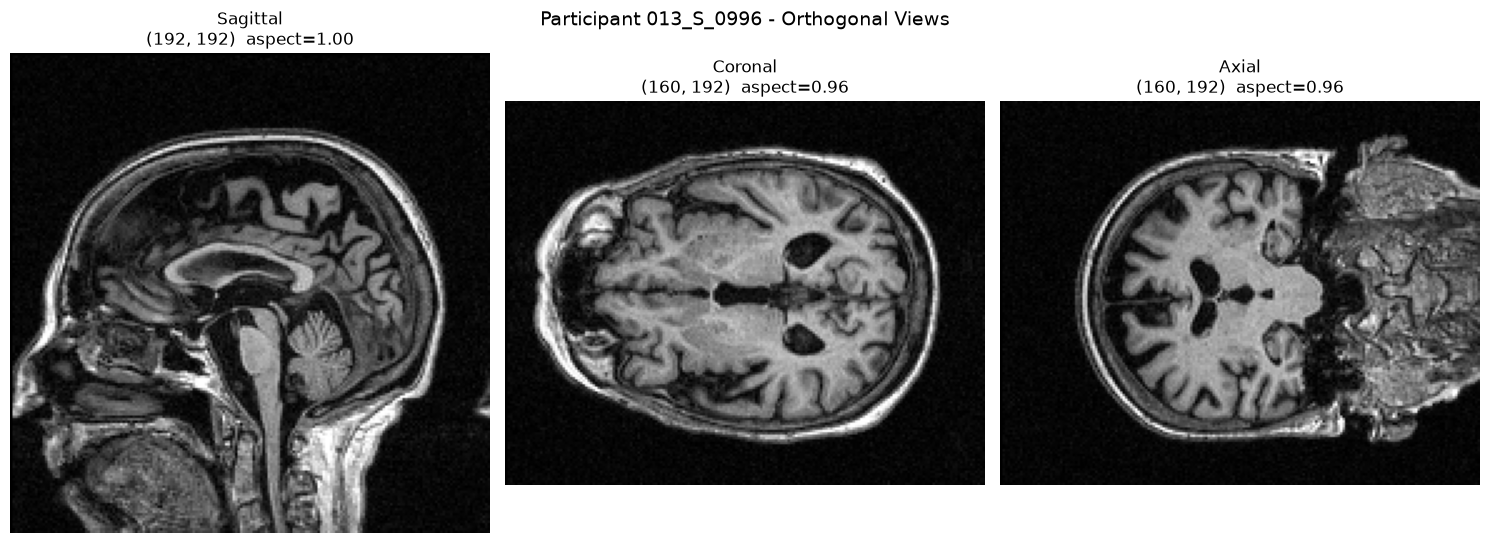

Voxel spacing: 1.200 x 1.250 x 1.250 mm


In [7]:
# ============================================================
# Orthogonal Planes with Correct Aspect Ratios
# ============================================================

row_spacing = info["row_spacing"]
column_spacing = info["column_spacing"]
slice_spacing = info["slice_spacing"]

views = [
    ("Sagittal", volume[volume.shape[0] // 2, :, :],
     row_spacing / column_spacing),
    ("Coronal", volume[:, volume.shape[1] // 2, :],
     slice_spacing / column_spacing),
    ("Axial", volume[:, :, volume.shape[2] // 2],
     slice_spacing / row_spacing),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

for ax, (name, image, aspect) in zip(axes, views):
    ax.imshow(image, cmap="gray", vmin=display_min, vmax=display_max,
              aspect=aspect)
    ax.set_title(f"{name}\n{image.shape}  aspect={aspect:.2f}")
    ax.axis("off")

plt.suptitle(f"Participant {participant_id} - Orthogonal Views", fontsize=14)
plt.tight_layout()
plt.show()

print("Voxel spacing: "
      f"{slice_spacing:.3f} x {row_spacing:.3f} x {column_spacing:.3f} mm")

if not np.isclose(slice_spacing, row_spacing, atol=0.05):
    print("\nVoxels are anisotropic. Any 3D volumetric measurement would need")
    print("resampling to isotropic spacing first.")

## 2.4 Cohort-Wide Acquisition Audit

Every participant's DICOM header is read to collect scanner manufacturer, model,
field strength and voxel geometry.

Why it matters: if — for example — most AD scans came from one scanner and most CN
scans from another, a convolutional network could achieve strong classification by
detecting scanner-specific intensity characteristics while learning nothing about
Alzheimer's disease. This is a well-documented failure mode in medical imaging, and
it is invisible unless explicitly checked.

Only header metadata is read here, not pixel data, so the scan is reasonably fast.

In [8]:
# ============================================================
# Audit Acquisition Parameters Across the Cohort
#
# Reads only the header of the first DICOM per participant.
# ============================================================

manifest = pd.read_csv(PROJECT_ROOT / "participant_manifest.csv")

print(f"Auditing {len(manifest)} participants...\n")

audit_rows = []
audit_failures = []

for number, row in enumerate(manifest.itertuples(), start=1):

    subject = row.Subject

    if number % 20 == 0 or number == len(manifest):
        print(f"  {number}/{len(manifest)}")

    try:
        series = find_mri_series(MRI_FOLDER / subject)[0]

        sample_file = next(series["path"].glob("*.dcm"))

        # Read only the header to avoid loading pixel data
        header = pydicom.dcmread(sample_file, stop_before_pixels=True)

        n_files = series["n_files"]

        audit_rows.append({
            "Subject": subject,
            "Group": row.Group,
            "Sequence": series["sequence"],
            "Slices": n_files,
            "Rows": int(getattr(header, "Rows", 0)),
            "Columns": int(getattr(header, "Columns", 0)),
            "Manufacturer": str(getattr(header, "Manufacturer", "Unknown")).strip(),
            "Model": str(getattr(header, "ManufacturerModelName", "Unknown")).strip(),
            "FieldStrength": float(getattr(header, "MagneticFieldStrength", np.nan)),
            "SliceThickness": float(getattr(header, "SliceThickness", np.nan)),
            "PixelSpacing": float(header.PixelSpacing[0])
                if hasattr(header, "PixelSpacing") else np.nan,
        })

    except Exception as error:
        audit_failures.append({"Subject": subject, "Error": str(error)})

audit = pd.DataFrame(audit_rows)

print(f"\nAudited successfully : {len(audit)}")
print(f"Failed               : {len(audit_failures)}")

if audit_failures:
    display(pd.DataFrame(audit_failures))

AUDIT_PATH = RESULTS_FOLDER / "acquisition_audit.csv"
audit.to_csv(AUDIT_PATH, index=False)
print(f"\nSaved: {AUDIT_PATH}")

Auditing 411 participants...

  20/411
  40/411
  60/411
  80/411
  100/411
  120/411
  140/411
  160/411
  180/411
  200/411
  220/411
  240/411
  260/411
  280/411
  300/411
  320/411
  340/411
  360/411
  380/411
  400/411
  411/411

Audited successfully : 411
Failed               : 0

Saved: C:\Users\aimen\Documents\GitHub\MSc-Final-Project\results\acquisition_audit.csv


In [9]:
# ============================================================
# Scanner Distribution
# ============================================================

print("Manufacturer")
display(audit["Manufacturer"].value_counts().to_frame("Participants"))

print("Field strength (Tesla)")
display(audit["FieldStrength"].value_counts(dropna=False).to_frame("Participants"))

print("Volume dimensions (slices x rows x columns)")
dimension_counts = (
    audit.groupby(["Slices", "Rows", "Columns"])
    .size().sort_values(ascending=False)
    .to_frame("Participants")
)
display(dimension_counts.head(10))

if len(dimension_counts) > 1:
    print(f"{len(dimension_counts)} distinct volume geometries present.")
    print("Resizing to a common 224x224 in Notebook 3 handles the in-plane")
    print("dimension differences. Variation in the number of acquired slices")
    print("is handled during the subsequent slice-selection stage.")

Manufacturer


,Participants
Manufacturer,
SIEMENS,367
Philips Medical Systems,44


Field strength (Tesla)


,Participants
FieldStrength,
1.49400,215
1.50000,86
2.89362,54
1.49400,37
3.00000,19


Volume dimensions (slices x rows x columns)


Participants
Slices Rows Columns              
160    192  192               307
       256  240                60
170    256  256                34
184    256  256                10

4 distinct volume geometries present.
Resizing to a common 224x224 in Notebook 3 handles the in-plane
dimension differences. Variation in the number of acquired slices
is handled during the subsequent slice-selection stage.


In [10]:
# ============================================================
# Batch-Effect Check: Scanner vs Diagnostic Group
#
# The question: is scanner hardware distributed evenly across
# CN / MCI / AD, or is it confounded with diagnosis?
# ============================================================

from scipy import stats

scanner_by_group = pd.crosstab(audit["Manufacturer"], audit["Group"])
scanner_by_group = scanner_by_group.reindex(columns=CLASS_NAMES, fill_value=0)

print("Manufacturer by diagnostic group")
display(scanner_by_group)

percentages = (
    scanner_by_group.div(scanner_by_group.sum(axis=0), axis=1) * 100
).round(1)

print("Column percentages (within each diagnostic group)")
display(percentages)

# ------------------------------------------------------------
# Test independence
# ------------------------------------------------------------

if scanner_by_group.shape[0] > 1 and scanner_by_group.shape[1] > 1:

    chi2, p_scanner, dof, expected = stats.chi2_contingency(scanner_by_group)

    print(f"Chi-square: chi2 = {chi2:.4f}, dof = {dof}, p = {p_scanner:.4f}")

    if expected.min() < 5:
        print(f"\nCAUTION: smallest expected count is {expected.min():.2f}.")
        print("Chi-square is unreliable below 5; read this as indicative only.")

    if p_scanner < 0.05:
        print("\n" + "!" * 58)
        print("SCANNER IS CONFOUNDED WITH DIAGNOSIS.")
        print("A CNN may separate the classes using scanner-specific image")
        print("characteristics rather than neuroanatomy. This must be")
        print("reported as a limitation, and ideally checked by testing")
        print("whether a model can predict scanner from the images.")
        print("!" * 58)
    else:
        print("\nNo significant association was detected between scanner")
        print("manufacturer and diagnostic group.")
        print("Batch effects from manufacturer are unlikely to explain")
        print("classification performance.")
      

else:
    print("Only one manufacturer or one group present - no test possible.")

Manufacturer by diagnostic group


Group,CN,MCI,AD
Manufacturer,,,
Philips Medical Systems,12,23,9
SIEMENS,105,178,84


Column percentages (within each diagnostic group)


Group,CN,MCI,AD
Manufacturer,,,
Philips Medical Systems,10.3,11.4,9.7
SIEMENS,89.7,88.6,90.3


Chi-square: chi2 = 0.2418, dof = 2, p = 0.8861

No significant association was detected between scanner
manufacturer and diagnostic group.
Batch effects from manufacturer are unlikely to explain
classification performance.


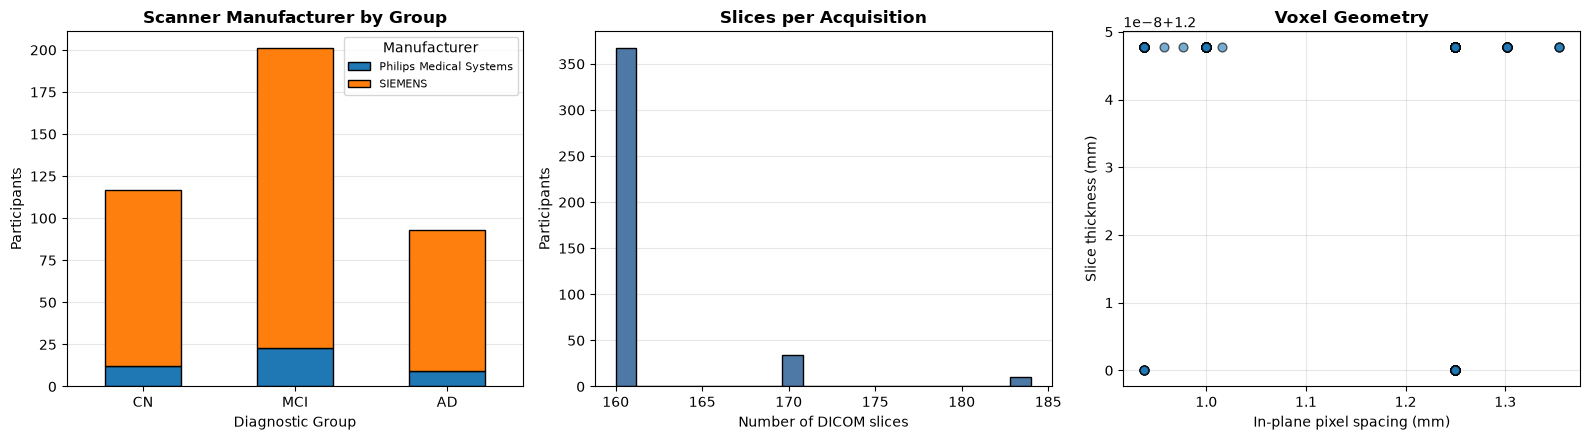

In [11]:
# ============================================================
# Acquisition Audit Visualisation
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ---- manufacturer by group ----
scanner_by_group.T.plot(kind="bar", stacked=True, ax=axes[0],
                        edgecolor="black")
axes[0].set_title("Scanner Manufacturer by Group", fontweight="bold")
axes[0].set_xlabel("Diagnostic Group")
axes[0].set_ylabel("Participants")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(fontsize=8, title="Manufacturer")
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_axisbelow(True)

# ---- slice count distribution ----
axes[1].hist(audit["Slices"], bins=20, color="#4E79A7", edgecolor="black")
axes[1].set_title("Slices per Acquisition", fontweight="bold")
axes[1].set_xlabel("Number of DICOM slices")
axes[1].set_ylabel("Participants")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_axisbelow(True)

# ---- voxel spacing ----
axes[2].scatter(audit["PixelSpacing"], audit["SliceThickness"],
                alpha=0.6, edgecolor="black", s=40)
axes[2].set_title("Voxel Geometry", fontweight="bold")
axes[2].set_xlabel("In-plane pixel spacing (mm)")
axes[2].set_ylabel("Slice thickness (mm)")
axes[2].grid(alpha=0.3)
axes[2].set_axisbelow(True)

plt.tight_layout()
plt.show()

## 2.5 Export the Shared Utility Module

The functions validated above are written to `src/mri_utils.py`. Notebooks 3 and 4
import from this module instead of redefining the same functions.

Using a shared utility module ensures that MRI loading and reconstruction are
performed consistently across the subsequent stages of the pipeline. Changes to
the MRI processing functions therefore need to be made in only one place.

The preprocessing functions used by notebooks 3 and 4 are also included so that
the common MRI processing steps are maintained in a single importable module.

In [15]:
# ============================================================
# Write src/mri_utils.py
#
# This is the single definition of the MRI pipeline. Notebooks 3
# and 4 import from it rather than redefining the same functions,
# which is how the three copies in the original project were able
# to diverge from one another.
# ============================================================

MRI_UTILS_SOURCE = '''
"""
Shared MRI utilities for the ADNI Alzheimer's classification project.

Generated by Notebook 2. Imported by Notebooks 3 and 4.

Do not edit this file directly. Edit the generating cell in Notebook 2 and
re-run it, so that the module and the notebook documenting it cannot drift
apart.
"""

from pathlib import Path

import numpy as np
import pydicom

from scipy import ndimage
from skimage.transform import resize


# ============================================================
# Default preprocessing parameters
# ============================================================

LOWER_PERCENTILE = 1
UPPER_PERCENTILE = 99

SIGNAL_THRESHOLD = 0.05
BRAIN_CONTENT_THRESHOLD = 0.70

N_SLICES_PER_PARTICIPANT = 20
IMAGE_SIZE = (224, 224)

# ============================================================
# Anatomical plane for 2D slicing
#
# Axis mapping verified from ImageOrientationPatient across 25
# scans spanning both manufacturers and all three matrix sizes
# in this cohort. Every scan gives row=Posterior, col=Inferior,
# normal=Right, so a fixed axis index is safe here:
#
#   axis 0 -> left-right         -> sagittal
#   axis 1 -> superior-inferior  -> axial
#   axis 2 -> anterior-posterior -> coronal
#
# Coronal is used because the hippocampus is the primary
# biomarker in this project, and coronal is the clinical
# standard plane for medial temporal lobe assessment.
# ============================================================

PLANE_AXIS = {"sagittal": 0, "axial": 1, "coronal": 2}
DEFAULT_PLANE = "coronal"


# ============================================================
# Series discovery
# ============================================================

def find_mri_series(participant_folder,
                    prefer=("MPRAGE", "MP-RAGE", "MP RAGE")):
    """Locate candidate DICOM series for a participant, best first."""

    participant_folder = Path(participant_folder)

    if not participant_folder.exists():
        raise FileNotFoundError(f"No folder for {participant_folder.name}")

    candidates = []

    for sequence_folder in sorted(participant_folder.iterdir()):
        if not sequence_folder.is_dir():
            continue
        for acquisition_folder in sorted(sequence_folder.iterdir()):
            if not acquisition_folder.is_dir():
                continue
            for series_folder in sorted(acquisition_folder.iterdir()):
                if not series_folder.is_dir():
                    continue
                dicom_files = list(series_folder.glob("*.dcm"))
                if not dicom_files:
                    continue
                candidates.append({
                    "path": series_folder,
                    "sequence": sequence_folder.name,
                    "acquisition": acquisition_folder.name,
                    "n_files": len(dicom_files),
                    "preferred": any(
                        t.lower() in sequence_folder.name.lower()
                        for t in prefer
                    ),
                })

    if not candidates:
        raise FileNotFoundError(
            f"No DICOM series found for {participant_folder.name}"
        )

    candidates.sort(key=lambda c: (not c["preferred"], -c["n_files"]))
    return candidates


# ============================================================
# Volume reconstruction
# ============================================================

def load_mri_volume(dicom_folder, enforce_single_series=True,
                    spacing_tolerance=0.30):
    """Load a DICOM series and reconstruct the anatomically ordered volume."""

    dicom_folder = Path(dicom_folder)
    dicom_files = list(dicom_folder.glob("*.dcm"))

    if not dicom_files:
        raise ValueError(f"No DICOM files in {dicom_folder}")

    slices = [pydicom.dcmread(f) for f in dicom_files]

    series_uids = {str(s.SeriesInstanceUID) for s in slices}

    if len(series_uids) > 1:
        message = (
            f"{len(series_uids)} SeriesInstanceUIDs in {dicom_folder.name} "
            f"- these are not a single acquisition"
        )
        if enforce_single_series:
            raise ValueError(message)

    orientation = np.array(slices[0].ImageOrientationPatient, dtype=float)
    slice_normal = np.cross(orientation[:3], orientation[3:])

    def slice_position(s):
        position = np.array(s.ImagePositionPatient, dtype=float)
        return float(np.dot(position, slice_normal))

    slices = sorted(slices, key=slice_position)

    positions = np.array([slice_position(s) for s in slices])
    spacings = np.abs(np.diff(positions))
    median_spacing = float(np.median(spacings)) if spacings.size else 0.0

    if spacings.size:
        uniform = bool(np.all(
            np.abs(spacings - median_spacing)
            <= spacing_tolerance * median_spacing
        ))
    else:
        uniform = True

    volume = np.stack([s.pixel_array for s in slices])

    first = slices[0]

    info = {
        "n_slices": len(slices),
        "shape": volume.shape,
        "row_spacing": float(first.PixelSpacing[0]),
        "column_spacing": float(first.PixelSpacing[1]),
        "slice_spacing": median_spacing,
        "spacing_uniform": uniform,
        "manufacturer": str(getattr(first, "Manufacturer", "Unknown")).strip(),
        "field_strength": float(
            getattr(first, "MagneticFieldStrength", np.nan)),
        "series_description": str(
            getattr(first, "SeriesDescription", "")).strip(),
        "n_series_uids": len(series_uids),
    }

    return volume, slices, info   

# ============================================================
# Intensity normalisation
# ============================================================

def normalize_volume(volume, lower=LOWER_PERCENTILE, upper=UPPER_PERCENTILE):
    """Percentile-clipped scaling to the range 0-1. Background stays zero."""

    nonzero = volume[volume > 0]

    if nonzero.size == 0:
        raise ValueError("Volume contains no non-zero voxels.")

    lower_value = np.percentile(nonzero, lower)
    upper_value = np.percentile(nonzero, upper)

    if upper_value <= lower_value:
        raise ValueError("Invalid intensity range for normalisation.")

    background = volume == 0

    normalized = np.clip(volume.astype(np.float32), lower_value, upper_value)
    normalized = (normalized - lower_value) / (upper_value - lower_value)
    normalized[background] = 0.0

    return normalized


def reorient(volume, plane=DEFAULT_PLANE):
    """
    Move the requested anatomical plane to axis 0 so the existing
    slice-selection code, which iterates axis 0, operates on it.

    The axis swap for coronal and axial is required. moveaxis alone
    yields a rotated image: measured left-right symmetry about the
    vertical midline on a mid-coronal slice is 0.26 without the
    swap and 0.65 with it.

    Resulting in-plane orientation:
      sagittal -> rows = superior-inferior, cols = anterior-posterior
      coronal  -> rows = superior-inferior, cols = left-right
      axial    -> rows = anterior-posterior, cols = left-right
    """

    if plane not in PLANE_AXIS:
        raise ValueError(
            f"plane must be one of {sorted(PLANE_AXIS)}, got {plane!r}"
        )

    out = np.moveaxis(volume, PLANE_AXIS[plane], 0)

    if plane in ("coronal", "axial"):
        out = np.swapaxes(out, 1, 2)

    return out

# ============================================================
# Brain extraction
# ============================================================

def extract_brain_mask(volume, threshold=0.10, erosion_iterations=3,
                       dilation_iterations=3):
    """
    Approximate skull stripping using morphological processing.

    Skull and scalp are bright on T1 and connect to brain tissue through
    the dura, so plain thresholding retains them. Eroding breaks those thin
    connections, the largest surviving component is the brain, and dilating
    restores the original extent.

    This is an approximate skull-stripping approach used before 2D slice extraction.
    It is not equivalent to a dedicated tool such as HD-BET or SynthStrip,
    and this limitation should be considered when interpreting the results.
    """

    mask = volume > threshold

    structure = np.ones((3, 3, 3))

    mask = ndimage.binary_erosion(
        mask, structure=structure, iterations=erosion_iterations)

    labelled, n_components = ndimage.label(mask)

    if n_components == 0:
        return np.ones_like(volume, dtype=bool)

    sizes = ndimage.sum(mask, labelled, range(1, n_components + 1))
    mask = labelled == (int(np.argmax(sizes)) + 1)

    mask = ndimage.binary_dilation(
        mask, structure=structure, iterations=dilation_iterations)

    mask = ndimage.binary_fill_holes(mask)

    return mask


def apply_brain_mask(volume, mask):
    """Zero every voxel outside the brain mask."""

    return volume * mask.astype(volume.dtype)


# ============================================================
# Slice selection
# ============================================================

def calculate_brain_content(volume, threshold=SIGNAL_THRESHOLD):
    """Percentage of pixels carrying meaningful signal, per slice."""

    return np.array([
        np.count_nonzero(s > threshold) / s.size * 100.0
        for s in volume
    ], dtype=np.float32)


def select_informative_slices(brain_content,
                              n_slices=N_SLICES_PER_PARTICIPANT,
                              content_fraction=BRAIN_CONTENT_THRESHOLD):
    """
    Choose n_slices evenly spaced across the informative slice range.

    The original pipeline returned every slice above the content threshold,
    producing roughly 86 contiguous, near-identical slices per participant.
    That inflated the apparent dataset size without adding information and
    was the principal cause of overfitting in the deep learning branch.

    Sampling evenly across the same anatomical range preserves coverage
    while removing the redundancy.
    """

    if brain_content.size == 0:
        raise ValueError("Empty brain-content profile.")

    threshold = brain_content.max() * content_fraction
    valid = np.where(brain_content >= threshold)[0]

    if valid.size == 0:
        raise ValueError("No slices exceed the brain-content threshold.")

    first, last = int(valid[0]), int(valid[-1])

    span = last - first + 1

    if n_slices >= span:
        return np.arange(first, last + 1)

    indices = np.linspace(first, last, n_slices)

    return np.unique(np.round(indices).astype(int))


def resize_slices(volume, indices, image_size=IMAGE_SIZE):
    """Resize the selected coronal slices to a common resolution."""

    return np.stack([
        resize(volume[i], image_size,
               preserve_range=True, anti_aliasing=True).astype(np.float32)
        for i in indices
    ])


# ============================================================
# End-to-end pipeline
# ============================================================

def preprocess_participant(participant_folder,
                           n_slices=N_SLICES_PER_PARTICIPANT,
                           skull_strip=True,
                           image_size=IMAGE_SIZE,
                           plane=DEFAULT_PLANE):
    """
    Run the full preprocessing pipeline for one participant.

    Returns (slices_array, metadata_dict).
    """

    series = find_mri_series(participant_folder)[0]

    volume, _, info = load_mri_volume(series["path"])

    normalized = normalize_volume(volume)

    if skull_strip:
        mask = extract_brain_mask(normalized)
        normalized = apply_brain_mask(normalized, mask)
        brain_fraction = float(mask.mean())
    else:
        brain_fraction = float("nan")

    # Reorient before slice profiling, so brain content and slice
    # selection operate on the requested plane.
    normalized = reorient(normalized, plane)

    content = calculate_brain_content(normalized)
    indices = select_informative_slices(content, n_slices=n_slices)
    slices_array = resize_slices(normalized, indices, image_size)

    metadata = {
        **info,
        "sequence": series["sequence"],
        "acquisition": series["acquisition"],
        "plane": plane,
        "reoriented_shape": list(normalized.shape),
        "selected_indices": indices.tolist(),
        "n_selected": int(len(indices)),
        "skull_stripped": bool(skull_strip),
        "brain_fraction": brain_fraction,
    }

    return slices_array, metadata
'''

MRI_UTILS_PATH = SRC_FOLDER / "mri_utils.py"

MRI_UTILS_PATH.write_text(MRI_UTILS_SOURCE, encoding="utf-8")

print(f"Written: {MRI_UTILS_PATH}")
print(f"Lines  : {len(MRI_UTILS_SOURCE.splitlines())}")

Written: C:\Users\aimen\Documents\GitHub\MSc-Final-Project\src\mri_utils.py
Lines  : 380


In [16]:
# ============================================================
# Verify the Shared Module
# ============================================================

import sys
import importlib

if str(SRC_FOLDER) not in sys.path:
    sys.path.insert(0, str(SRC_FOLDER))

import mri_utils
importlib.reload(mri_utils)

print("Module imported. Public functions:")
for name in sorted(dir(mri_utils)):
    if not name.startswith("_") and callable(getattr(mri_utils, name)):
        print(f"  {name}")

# ------------------------------------------------------------
# Confirm that the module reproduces the same reconstruction
# ------------------------------------------------------------

module_volume, _, module_info = mri_utils.load_mri_volume(dicom_folder)

assert module_volume.shape == volume.shape, "Module volume shape differs"
assert np.array_equal(module_volume, volume), "Module volume contents differ"

print("\nModule reproduces the in-notebook reconstruction exactly.")

# ------------------------------------------------------------
# Check informative-slice selection
# ------------------------------------------------------------

test_normalized = mri_utils.normalize_volume(volume)
test_content = mri_utils.calculate_brain_content(test_normalized)

threshold_indices = np.where(
    test_content >= test_content.max() * mri_utils.BRAIN_CONTENT_THRESHOLD
)[0]

selected_indices = mri_utils.select_informative_slices(
    test_content,
    n_slices=20
)

print(f"\nSlice selection check for {participant_id}:")
print(f"  Slices above content threshold : {len(threshold_indices)}")
print(f"  Evenly selected slices         : {len(selected_indices)}")
print(f"  Range covered                  : "
      f"{selected_indices.min()} to {selected_indices.max()}")

# ------------------------------------------------------------
# Confirm reorientation geometry
# ------------------------------------------------------------

print("\nReorientation check:")

for plane in ["sagittal", "coronal", "axial"]:
    reoriented = mri_utils.reorient(test_normalized, plane)

    print(
        f"  {plane:<9}: "
        f"{volume.shape} -> {reoriented.shape}  "
        f"({reoriented.shape[0]} slices of "
        f"{reoriented.shape[1]}x{reoriented.shape[2]})"
    )

Module imported. Public functions:
  Path
  apply_brain_mask
  calculate_brain_content
  extract_brain_mask
  find_mri_series
  load_mri_volume
  normalize_volume
  preprocess_participant
  reorient
  resize
  resize_slices
  select_informative_slices


c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.02871115258695046335'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)



Module reproduces the in-notebook reconstruction exactly.

Slice selection check for 013_S_0996:
  Slices above content threshold : 82
  Evenly selected slices         : 20
  Range covered                  : 38 to 119

Reorientation check:
  sagittal : (160, 192, 192) -> (160, 192, 192)  (160 slices of 192x192)
  coronal  : (160, 192, 192) -> (192, 192, 160)  (192 slices of 192x160)
  axial    : (160, 192, 192) -> (192, 192, 160)  (192 slices of 192x160)


In [17]:
# ============================================================
# Notebook 2 Summary
# ============================================================

print("=" * 58)
print("        MRI RECONSTRUCTION AND AUDIT SUMMARY")
print("=" * 58)

print(f"Example participant        : {participant_id}")
print(f"Sequence                   : {info['series_description']}")
print(f"Manufacturer               : {info['manufacturer']}")
print(f"Volume shape               : {info['shape']}")
print(f"Voxel spacing (mm)         : "
      f"{info['slice_spacing']:.2f} x {info['row_spacing']:.2f} "
      f"x {info['column_spacing']:.2f}")
print(f"Single series confirmed    : {info['n_series_uids'] == 1}")
print(f"Spacing uniform            : {info['spacing_uniform']}")

print()
print(f"Cohort audited             : {len(audit)} participants")
print(f"Manufacturers present      : {audit['Manufacturer'].nunique()}")
print(f"Distinct volume geometries : {len(dimension_counts)}")
print(f"Slices per scan            : {audit['Slices'].min()} to "
      f"{audit['Slices'].max()} (median {audit['Slices'].median():.0f})")

print()
print(f"Shared module written      : {MRI_UTILS_PATH.name}")

print()
print("Next: Notebook 3 imports mri_utils and applies the preprocessing")
print("pipeline, including brain extraction and sparse slice sampling.")
print("=" * 58)

        MRI RECONSTRUCTION AND AUDIT SUMMARY
Example participant        : 013_S_0996
Sequence                   : MPRAGE
Manufacturer               : SIEMENS
Volume shape               : (160, 192, 192)
Voxel spacing (mm)         : 1.20 x 1.25 x 1.25
Single series confirmed    : True
Spacing uniform            : True

Cohort audited             : 411 participants
Manufacturers present      : 2
Distinct volume geometries : 4
Slices per scan            : 160 to 184 (median 160)

Shared module written      : mri_utils.py

Next: Notebook 3 imports mri_utils and applies the preprocessing
pipeline, including brain extraction and sparse slice sampling.
